##Task 3 — Heart Disease Prediction

## Objective

The objective of this project is to build a machine learning model that predicts whether a person is at risk of heart disease based on medical attributes. The project includes data preprocessing, exploratory data analysis (EDA), model training, evaluation, and visualization using Python libraries.

In [27]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

## Load Dataset

In this step, we load the heart disease dataset into a pandas DataFrame for analysis and model training.

In [28]:
# Load dataset

df = pd.read_csv('heart_disease_uci.csv')

# Display first 5 rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Dataset Inspection

This section helps us understand the structure, columns, and statistical information of the dataset.

In [29]:
# Shape of dataset

print("Dataset Shape:", df.shape)

Dataset Shape: (920, 16)


In [30]:
# Column names

print("Columns in Dataset:\n")
print(df.columns)

Columns in Dataset:

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [31]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [32]:
# Statistical summary

df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Data Cleaning

In this step, we handle missing values and prepare the dataset for machine learning.

In [33]:
# Check missing values

print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [34]:
# Remove missing values

df = df.dropna()

In [35]:
# Verify missing values removed

print(df.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


## Exploratory Data Analysis (EDA)

EDA helps understand relationships, distributions, and patterns in the dataset.

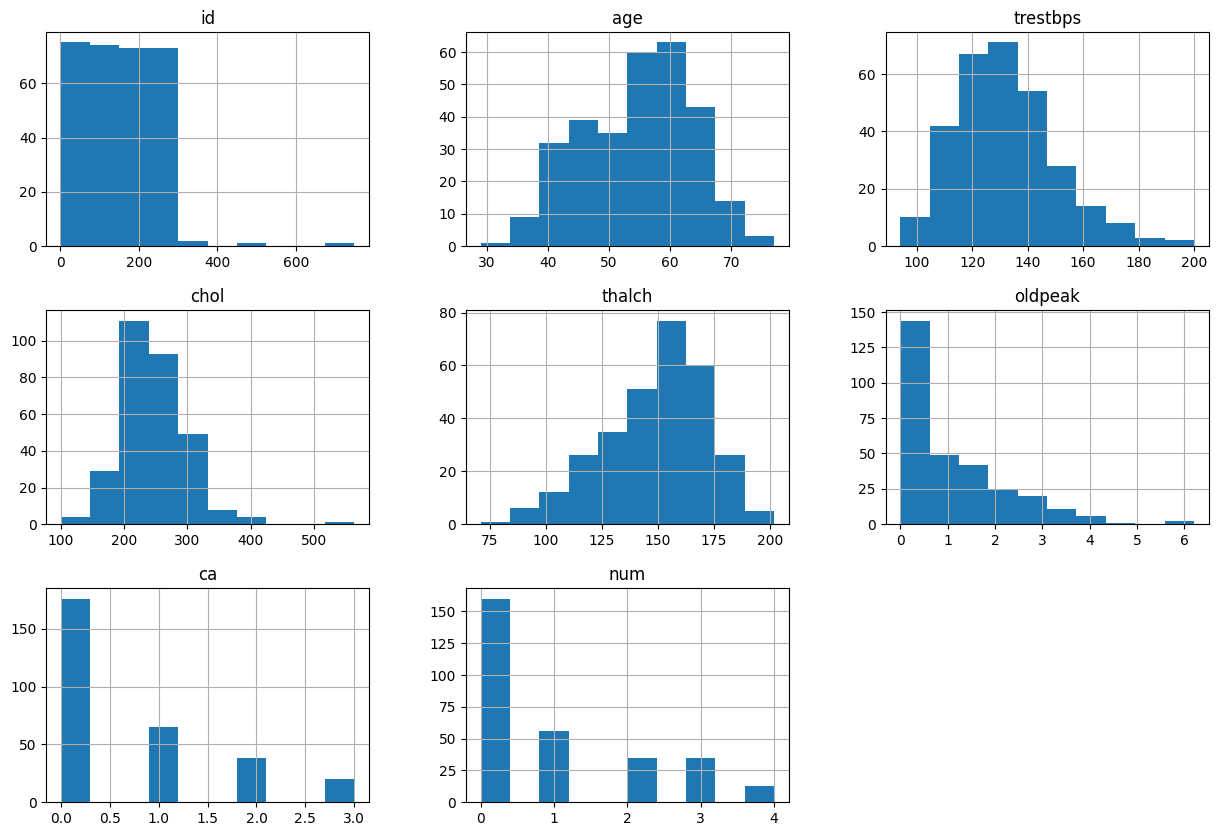

In [36]:
# Histogram of all numerical features

df.hist(figsize=(15,10))
plt.show()

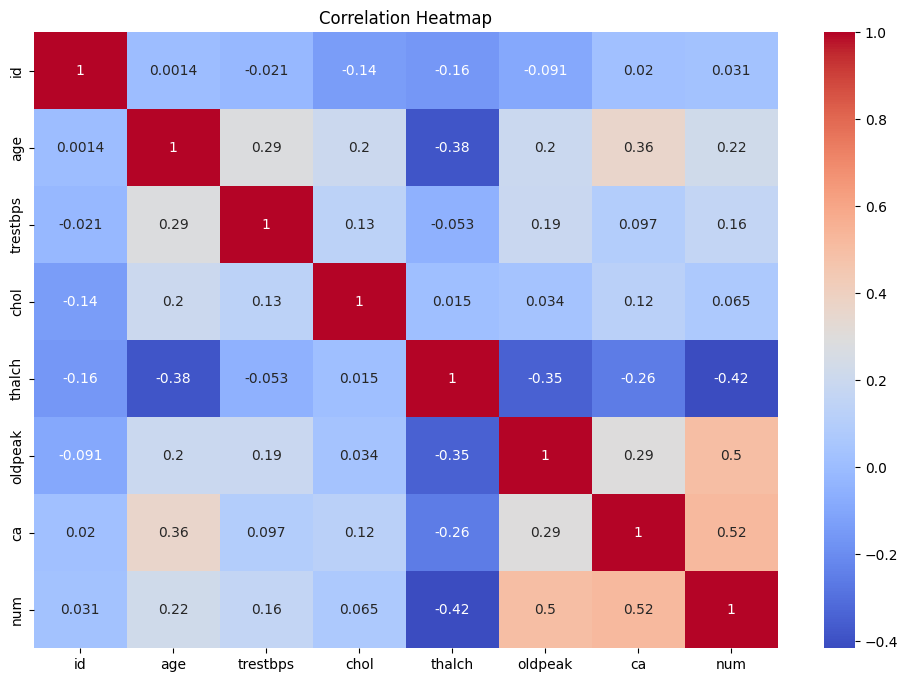

In [37]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

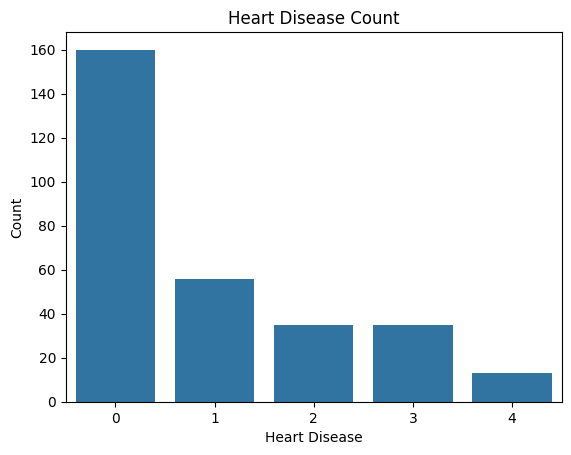

In [38]:
# Count plot for target variable

sns.countplot(x='num', data=df)

plt.title("Heart Disease Count")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

## Feature Selection

Features are selected for training the machine learning model.

In [39]:
# Select features and target

X = df.drop('num', axis=1)
y = df['num']

## Convert Target Variable

Convert heart disease values into binary classification:
- 0 = No Disease
- 1 = Disease

In [40]:
# Convert target into binary classes

y = y.apply(lambda x: 1 if x > 0 else 0)

## Handle Categorical Features

Machine learning models require numerical data, so categorical columns are converted.

In [41]:
# Convert categorical columns into numeric

X = pd.get_dummies(X, drop_first=True)

## Train-Test Split

The dataset is divided into training and testing sets.

In [42]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training

Logistic Regression model is used for prediction.

In [43]:
# Create model

model = LogisticRegression(max_iter=5000)

# Train model

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

## Prediction

The trained model predicts heart disease on test data.

In [44]:
# Predict values

y_pred = model.predict(X_test)

## Model Evaluation

Evaluate model performance using accuracy score and classification report.

In [45]:
# Accuracy score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.9166666666666666


In [46]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93        35
           1       0.88      0.92      0.90        25

    accuracy                           0.92        60
   macro avg       0.91      0.92      0.91        60
weighted avg       0.92      0.92      0.92        60



## Confusion Matrix

Confusion matrix helps visualize prediction performance.

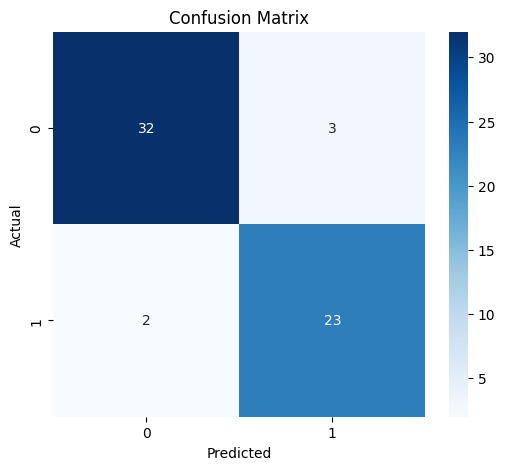

In [47]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## ROC Curve

ROC curve evaluates classification performance.

In [48]:
# Predict probabilities

y_prob = model.predict_proba(X_test)[:,1]

In [49]:
# Calculate ROC values

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_score = roc_auc_score(y_test, y_prob)

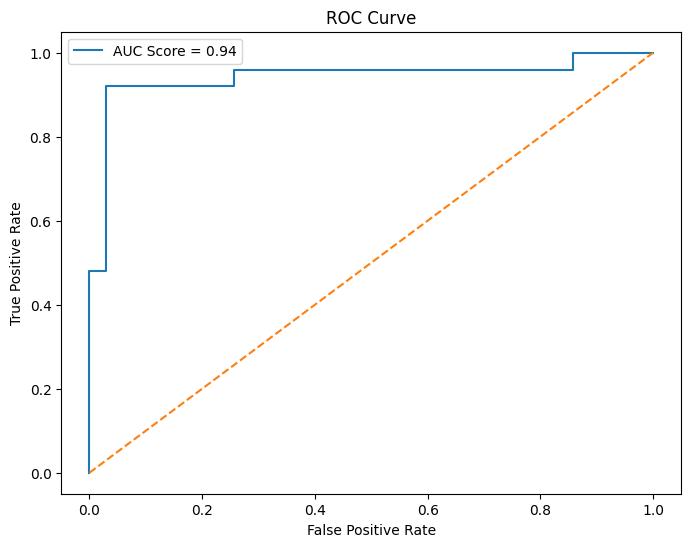

In [50]:
# Plot ROC Curve

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC Score = {roc_score:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Feature Importance

Feature importance shows which attributes contribute most to heart disease prediction.

In [51]:
# Feature importance using model coefficients

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
7,sex_Male,1.197184
6,ca,1.073415
16,exang_True,0.913481
20,thal_reversable defect,0.623123
17,slope_flat,0.507325
5,oldpeak,0.392658
9,dataset_VA Long Beach,0.041783
2,trestbps,0.018635
8,dataset_Hungary,0.017505
3,chol,0.003934


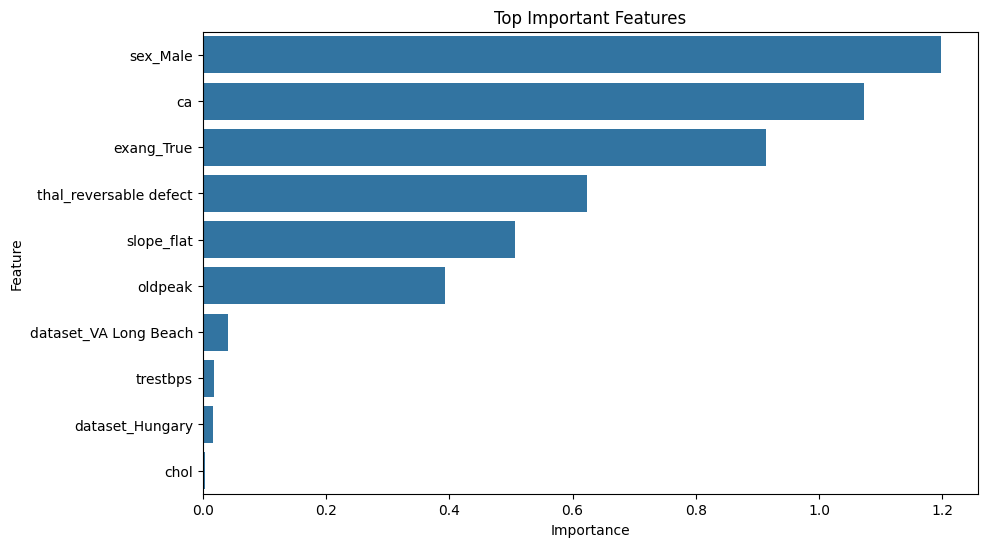

In [52]:
# Plot top important features

top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Important Features")

plt.show()

## Conclusion

In this project, a Logistic Regression model was developed to predict heart disease using medical data. The dataset was cleaned, analyzed, and visualized using different techniques. The model achieved good prediction accuracy and important health-related features were identified successfully.